In [2]:
# Imports
import numpy as np
import os as os
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import tqdm
import time
import pandas as pd
plt.rcParams['figure.dpi'] = 300

In [6]:
#
files = glob.glob('/home/chinahg/GCresearch/GRUAN_sondes/ftp.ncdc.noaa.gov/pub/data/gruan/processing/level2/RS92-GDP/version-002/' + '/**/*.nc', recursive=True)
num_files = len(files)

xls = pd.ExcelFile('GRUAN_site_data.xlsx')
df_GRUAN_sites = pd.read_excel(xls, '30-60lat')

#print the column names
print(df_GRUAN_sites.columns)

#get the values for a given column
values = df_GRUAN_sites['Code'].values
print(values)

Index(['Code', 'Name', 'Latitude', 'Longitude', 'Altitude [m]',
       'WMO/WIGOS No.', 'Status'],
      dtype='object')
['BEL' 'BOU' 'CAB' 'DLG' 'GRA' 'LIN' 'PAY' 'POT' 'SGP' 'TAT' 'TRP' 'XIL']


In [7]:
# # View data
# ds = xr.open_dataset(path2file)
# ds

In [8]:
# 10km is approx 265 hPa
start_time = time.time()
print("Started!")
#print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))

cruiseRH = []
MLD_array_pres = []
MLD_top = 0
MLD_bottom = 0
MLD_array_alt = []

L = -6.5*10**-3 # lapse rate [K/m]
P0 = 101325 # pressure at 0 alt [Pa]
T0 = 288.15 # temp at 0 alt [K]
R = 287.053 # gas constant for air [J/kgK]
g = 9.81 #acceleration due to gravity [m/s^2]

T_t = 273.16 # Ice triple point temp [K]
P_ip = 6.12 # Ice triple point pressure [hPa]

press_upper = 250
press_lower = 290
alt_upper = (T0/L)*((press_upper*100/P0)**(-L*R/g) - 1) # Upper altitude limit
alt_lower = (T0/L)*((press_lower*100/P0)**(-R*L/g) -1) # Lower altitude limit
print(alt_lower)
print(alt_upper)

for k in tqdm.tqdm(range(num_files)): # Look through all GRUAN radiosonde files
    #print("--- %s minutes elapsed ---" % round(time.time()/60 - start_time/60,2))
    #print("Processing file %s out of %s" % (k,num_files))
    path2file = files[k]

    # Read file in the location of interest
    nc_GRUAN = nc.Dataset(path2file, 'r', format='NETCDF4_CLASSIC')
    altitudes = nc_GRUAN.variables['alt'][:] # [m]
    RH_w = nc_GRUAN.variables['rh'][:]*100 # [%]
    T = nc_GRUAN.variables['temp'][:] # [K]
    P_sat_w = 6.112*np.exp((17.67*(T-273.15))/((T-273.15)+243.5)) *100 # [Pa] Bolton 1980
    P_sat_i =  6.112*np.exp(22.46*(T-273.15)/(272.62 + (T-273.15))) *100 # [Pa] Guide to Meteorological Instruments and Methods of Observation (CIMO Guide) (WMO, 2008)
    RH_i = RH_w*P_sat_w/P_sat_i # [%]
    RH_len = len(RH_i)

    for i in range(RH_len): # look through all RH datapoints for all dates and locations

        if altitudes[i] >= alt_lower and altitudes[i] <= alt_upper and RH_i[i] >= 100: # if pressure is approx 265 hPa and RH > 100% record RH
            # Save supersaturated RH value
            cruiseRH.append(RH_i[i])

            # Save altitude where supersaturated RH starts
            MLD_top = altitudes[i]

            for j in range(i): # Look through list of RH under cruise alt and determine MLD
                
                if RH_i[i-j] < 100: # MLD ends when RHi < 100%
                    MLD_index = i-j
                    MLD_bottom = altitudes[MLD_index]
                    break
                elif j == i:
                    MLD_bottom = altitudes[0]
                    break
            # Now have an array of RH and MLD upper and lower bounds
            # Take difference of altitudes to get MLD in [m]
            MLD_array_alt.append(MLD_top-MLD_bottom)

    

    # MLD_array_alt is appended to for each file, never overwritten
    # cruiseRH is appended to for each file, never overwritten

Started!
9387.218257311777
10359.854482111912


100%|██████████| 37534/37534 [36:33<00:00, 17.11it/s]  


In [ ]:
# Save the data so we don't have to process it again
import csv

# Specify the file path
file_path_MLD = 'GRUAN_MLD.csv'

# Open the file in write mode
with open(file_path_MLD, 'w', newline='') as csvfile:
    # Create a CSV writer object
    writer = csv.writer(csvfile)
    
    # Write the array to the CSV file
    writer.writerow(MLD_array_alt)

# Specify the file path
file_path_RH = 'GRUAN_RH.csv'

# Open the file in write mode
with open(file_path_RH, 'w', newline='') as csvfile:
    # Create a CSV writer object
    writer = csv.writer(csvfile)
    
    # Write the array to the CSV file
    writer.writerow(cruiseRH)

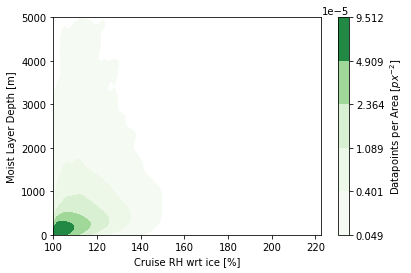

In [9]:
plt.rcParams['figure.dpi'] = 300
ax = sns.kdeplot(x = cruiseRH, y = MLD_array_alt, bw_adjust=1, zorder=0, fill=True, 
    cbar=True, cmap='Greens', cbar_kws={'label': 'Datapoints per Area [$px^{-2}$]'}, n_levels=6)

# ax = sns.kdeplot(x = cruiseRH[500:1000], y = MLD_array_alt[500:1000], bw_adjust=1, zorder=0, fill=True, 
#     cbar=True, cmap='Reds', alpha = 0.76, n_levels=6)
ax.set(xlabel = "Cruise RH wrt ice [%]")
ax.set(ylabel = "Moist Layer Depth [m]")
plt.rcParams['figure.dpi'] = 300
plt.ylim(bottom = 0, top = 5000)
plt.xlim(left = 100)
plt.show()

In [1]:
fig, ax = plt.subplots()
ax.hist2d(x = cruiseRH, y = MLD_array_alt, bins=5)

# ax = sns.kdeplot(x = cruiseRH[500:1000], y = MLD_array_alt[500:1000], bw_adjust=1, zorder=0, fill=True, 
#     cbar=True, cmap='Reds', alpha = 0.76, n_levels=6)
ax.set(xlabel = "Cruise RH wrt ice [%]")
ax.set(ylabel = "Moist Layer Depth [m]")
plt.rcParams['figure.dpi'] = 300
plt.ylim(bottom = 0, top = 5000)
plt.xlim(left = 100)
plt.show()

NameError: name 'plt' is not defined

In [3]:
# Specify the file path
file_path = 'GRUAN_data_processed.csv'

# Read the array from the CSV file
MLD_array_alt = np.genfromtxt(file_path, delimiter=',')
